In [1]:
import pandas as pd
import numpy as np


import re
import warnings 
import requests
from bs4 import BeautifulSoup
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta

In [2]:
df = pd.read_csv(
    "C:/Users/mundh/Videos/Screen Recordings/laptop_raw_data.csv")
df.head()

,Product Title,Product Price,Product Rating,Product Review,Product Feature,Product Discount
0,HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...,"₹40,990",4.2,"2,454 Ratings & 147 Reviews",Intel Core i3 Processor (13th Gen)16 GB DDR4 R...,19% off
1,ASUS Expertbook P1 High-performance processor ...,"₹55,990",4.3,"4,183 Ratings & 324 Reviews",Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51% off
2,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,"₹24,699",3.8,"7,917 Ratings & 693 Reviews",Intel Celeron Dual Core Processor8 GB DDR4 RAM...,31% off
3,"HP 15 Laptop with Backlit Keyboard & MSO'2024,...","₹55,990",4.5,28 Ratings & 5 Reviews,AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,11% off
4,Acer Aspire 3 Backlit AMD Ryzen 7 Octa Core 77...,"₹43,990",4.1,"1,638 Ratings & 123 Reviews",AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,45% off


In [3]:
df

,Product Title,Product Price,Product Rating,Product Review,Product Feature,Product Discount
0,HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...,"₹40,990",4.2,"2,454 Ratings & 147 Reviews",Intel Core i3 Processor (13th Gen)16 GB DDR4 R...,19% off
1,ASUS Expertbook P1 High-performance processor ...,"₹55,990",4.3,"4,183 Ratings & 324 Reviews",Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51% off
2,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,"₹24,699",3.8,"7,917 Ratings & 693 Reviews",Intel Celeron Dual Core Processor8 GB DDR4 RAM...,31% off
3,"HP 15 Laptop with Backlit Keyboard & MSO'2024,...","₹55,990",4.5,28 Ratings & 5 Reviews,AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,11% off
4,Acer Aspire 3 Backlit AMD Ryzen 7 Octa Core 77...,"₹43,990",4.1,"1,638 Ratings & 123 Reviews",AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,45% off
...,...,...,...,...,...,...
883,MSI Prestige 16Studio Intel Core i7 13th Gen 1...,"₹1,63,990",NaN,NaN,Intel Core i7 Processor (13th Gen)16 GB LPDDR5...,18% off
884,ASUS Vivobook S14 (2025) with Office 2024 + M3...,"₹54,990",4.5,806 Ratings & 59 Reviews,Qualcomm Snapdragon X Processor16 GB LPDDR5X R...,40% off
885,ASUS Expertbook Intel Core i5 13th Gen 13420H ...,"₹55,990",4.2,202 Ratings & 10 Reviews,Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51% off
886,Lenovo IdeaPad Slim 3 Intel Core i3 11th Gen -...,"₹34,960",4.2,743 Ratings & 37 Reviews,Intel Core i3 Processor (11th Gen)8 GB DDR4 RA...,28% off


In [6]:
df.shape

(888, 6)

In [7]:
df.iloc[0]

Product Title       HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...
Product Price                                                 ₹40,990
Product Rating                                                    4.2
Product Review                            2,454 Ratings & 147 Reviews
Product Feature     Intel Core i3 Processor (13th Gen)16 GB DDR4 R...
Product Discount                                              19% off
Name: 0, dtype: object

In [8]:
df.shape[0]

888

In [9]:
df.dtypes

Product Title        object
Product Price        object
Product Rating      float64
Product Review       object
Product Feature      object
Product Discount     object
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 888 entries, 0 to 887
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Title     888 non-null    object 
 1   Product Price     888 non-null    object 
 2   Product Rating    819 non-null    float64
 3   Product Review    819 non-null    object 
 4   Product Feature   888 non-null    object 
 5   Product Discount  872 non-null    object 
dtypes: float64(1), object(5)
memory usage: 41.8+ KB


In [11]:
df.isnull().sum()

Product Title        0
Product Price        0
Product Rating      69
Product Review      69
Product Feature      0
Product Discount    16
dtype: int64

In [14]:
df.isnull().sum().sum()

np.int64(154)

In [13]:
df.dropna(inplace = True)

In [14]:
df.isnull().sum()

Product Title       0
Product Price       0
Product Rating      0
Product Review      0
Product Feature     0
Product Discount    0
dtype: int64

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df.columns

Index(['Product Title', 'Product Price', 'Product Rating', 'Product Review',
       'Product Feature', 'Product Discount'],
      dtype='object')

In [17]:
# Rename the column name
df.rename(columns={
    'Product Price': 'Price',
    'Product Rating': 'Rating',
    'Product Discount': 'Discount'
}, inplace=True)

In [19]:
#6.1.Cleaning product_rating:
df['Rating'] = df['Rating'].astype(str)
df['Rating'] = df['Rating'].str.extract(r'(\d\.\d)')
df['Rating'] = df['Rating'].astype(float)

In [20]:
# cleaning product discount
df['Discount'] = df['Discount'].astype(str)
df['Discount'] = df['Discount'].str.extract(r'(\d+)')
df['Discount'] = df['Discount'].astype(float)

In [21]:
# cleaning product price
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('₹', '', regex=False)
df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = df['Price'].astype(float)

In [34]:
# Split the Column Rating and review
df['Total_Ratings'] = (df['Product Review'].str.extract(r'([\d,]+)\sRatings')[0]
.str.replace(',', '').astype(float))

In [35]:
df['Total_Reviews'] = (
    df['Product Review']
    .str.extract(r'&\s([\d,]+)\sReviews')[0]
    .str.replace(',', '')
    .astype(float))

In [36]:
df

,Product Title,Price,Rating,Product Review,Product Feature,Discount,Processor,RAM,Total_Ratings,Total_Reviews
0,HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...,40990.0,4.2,"2,454 Ratings & 147 Reviews",Intel Core i3 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i3 Processor (13th Gen),16 GB DDR4 RAM,2454.0,147.0
1,ASUS Expertbook P1 High-performance processor ...,55990.0,4.3,"4,183 Ratings & 324 Reviews",Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen),32 GB DDR5 RAM,4183.0,324.0
2,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,24699.0,3.8,"7,917 Ratings & 693 Reviews",Intel Celeron Dual Core Processor8 GB DDR4 RAM...,31.0,Intel Celeron Dual Core Processor,8 GB DDR4 RAM,7917.0,693.0
3,"HP 15 Laptop with Backlit Keyboard & MSO'2024,...",55990.0,4.5,28 Ratings & 5 Reviews,AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,11.0,AMD Ryzen 7 Octa Core Processor,16 GB DDR4 RAM,28.0,5.0
4,Acer Aspire 3 Backlit AMD Ryzen 7 Octa Core 77...,43990.0,4.1,"1,638 Ratings & 123 Reviews",AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,45.0,AMD Ryzen 7 Octa Core Processor,16 GB DDR4 RAM,1638.0,123.0
...,...,...,...,...,...,...,...,...,...,...
804,HP 15 Intel Core i5 13th Gen 1335U - (16 GB/51...,52490.0,4.2,"1,232 Ratings & 63 Reviews",Intel Core i5 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i5 Processor (13th Gen),16 GB DDR4 RAM,1232.0,63.0
805,DELL Inspiron 5440 Intel Core i5 13th Gen 1334...,67990.0,4.2,21 Ratings & 2 Reviews,Intel Core i5 Processor (13th Gen)16 GB DDR5 R...,15.0,Intel Core i5 Processor (13th Gen),16 GB DDR5 RAM,21.0,2.0
806,ASUS Vivobook S14 (2025) with Office 2024 + M3...,54990.0,4.5,806 Ratings & 59 Reviews,Qualcomm Snapdragon X Processor16 GB LPDDR5X R...,40.0,Qualcomm Snapdragon X Processor,16 GB LPDDR5X RAM,806.0,59.0
807,ASUS Expertbook Intel Core i5 13th Gen 13420H ...,55990.0,4.2,202 Ratings & 10 Reviews,Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen),32 GB DDR5 RAM,202.0,10.0


In [10]:
# Create New columns for RAM
regex = r"\d+\sGB[\s\w]*RAM"
df["RAM"] = df['Product Feature'].apply(lambda x: re.findall(regex, x)[0] if re.findall(regex, x) else None)
df

,Product Title,Price,Rating,Product Review,Product Feature,Discount,Processor,RAM
0,HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...,40990.0,4.2,"2,454 Ratings & 147 Reviews",Intel Core i3 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i3 Processor (13th Gen),16 GB DDR4 RAM
1,ASUS Expertbook P1 High-performance processor ...,55990.0,4.3,"4,183 Ratings & 324 Reviews",Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen),32 GB DDR5 RAM
2,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,24699.0,3.8,"7,917 Ratings & 693 Reviews",Intel Celeron Dual Core Processor8 GB DDR4 RAM...,31.0,Intel Celeron Dual Core Processor,8 GB DDR4 RAM
3,"HP 15 Laptop with Backlit Keyboard & MSO'2024,...",55990.0,4.5,28 Ratings & 5 Reviews,AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,11.0,AMD Ryzen 7 Octa Core Processor,16 GB DDR4 RAM
4,Acer Aspire 3 Backlit AMD Ryzen 7 Octa Core 77...,43990.0,4.1,"1,638 Ratings & 123 Reviews",AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,45.0,AMD Ryzen 7 Octa Core Processor,16 GB DDR4 RAM
...,...,...,...,...,...,...,...,...
804,HP 15 Intel Core i5 13th Gen 1335U - (16 GB/51...,52490.0,4.2,"1,232 Ratings & 63 Reviews",Intel Core i5 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i5 Processor (13th Gen),16 GB DDR4 RAM
805,DELL Inspiron 5440 Intel Core i5 13th Gen 1334...,67990.0,4.2,21 Ratings & 2 Reviews,Intel Core i5 Processor (13th Gen)16 GB DDR5 R...,15.0,Intel Core i5 Processor (13th Gen),16 GB DDR5 RAM
806,ASUS Vivobook S14 (2025) with Office 2024 + M3...,54990.0,4.5,806 Ratings & 59 Reviews,Qualcomm Snapdragon X Processor16 GB LPDDR5X R...,40.0,Qualcomm Snapdragon X Processor,16 GB LPDDR5X RAM
807,ASUS Expertbook Intel Core i5 13th Gen 13420H ...,55990.0,4.2,202 Ratings & 10 Reviews,Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen),32 GB DDR5 RAM


In [8]:
# Create New columns for Processor
regex = r'(?:Intel|MediaTek|Apple|AMD|Qualcomm|Snapdragon)[\s\w\(\)]+Processor(?:\s\([\d+\w+\s]+\))?'
df["Processor"] = df['Product Feature'].apply(lambda x: re.findall(regex, x)[0] if re.findall(regex, x) else None)
df

,Product Title,Price,Rating,Product Review,Product Feature,Discount,Processor
0,HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...,40990.0,4.2,"2,454 Ratings & 147 Reviews",Intel Core i3 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i3 Processor (13th Gen)
1,ASUS Expertbook P1 High-performance processor ...,55990.0,4.3,"4,183 Ratings & 324 Reviews",Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen)
2,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,24699.0,3.8,"7,917 Ratings & 693 Reviews",Intel Celeron Dual Core Processor8 GB DDR4 RAM...,31.0,Intel Celeron Dual Core Processor
3,"HP 15 Laptop with Backlit Keyboard & MSO'2024,...",55990.0,4.5,28 Ratings & 5 Reviews,AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,11.0,AMD Ryzen 7 Octa Core Processor
4,Acer Aspire 3 Backlit AMD Ryzen 7 Octa Core 77...,43990.0,4.1,"1,638 Ratings & 123 Reviews",AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,45.0,AMD Ryzen 7 Octa Core Processor
...,...,...,...,...,...,...,...
804,HP 15 Intel Core i5 13th Gen 1335U - (16 GB/51...,52490.0,4.2,"1,232 Ratings & 63 Reviews",Intel Core i5 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i5 Processor (13th Gen)
805,DELL Inspiron 5440 Intel Core i5 13th Gen 1334...,67990.0,4.2,21 Ratings & 2 Reviews,Intel Core i5 Processor (13th Gen)16 GB DDR5 R...,15.0,Intel Core i5 Processor (13th Gen)
806,ASUS Vivobook S14 (2025) with Office 2024 + M3...,54990.0,4.5,806 Ratings & 59 Reviews,Qualcomm Snapdragon X Processor16 GB LPDDR5X R...,40.0,Qualcomm Snapdragon X Processor
807,ASUS Expertbook Intel Core i5 13th Gen 13420H ...,55990.0,4.2,202 Ratings & 10 Reviews,Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen)


# Clean The Data 

In [27]:
df.to_csv("cleaned_data.csv", index=False) # Save the csv file

In [5]:
df = pd.read_csv(r"C:\Users\mundh\Videos\Captures\cleaned_data.csv")

In [6]:
df

,Product Title,Price,Rating,Product Review,Product Feature,Discount,Processor,RAM
0,HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...,40990.0,4.2,"2,454 Ratings & 147 Reviews",Intel Core i3 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i3 Processor (13th Gen),16 GB DDR4 RAM
1,ASUS Expertbook P1 High-performance processor ...,55990.0,4.3,"4,183 Ratings & 324 Reviews",Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen),32 GB DDR5 RAM
2,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,24699.0,3.8,"7,917 Ratings & 693 Reviews",Intel Celeron Dual Core Processor8 GB DDR4 RAM...,31.0,Intel Celeron Dual Core Processor,8 GB DDR4 RAM
3,"HP 15 Laptop with Backlit Keyboard & MSO'2024,...",55990.0,4.5,28 Ratings & 5 Reviews,AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,11.0,AMD Ryzen 7 Octa Core Processor,16 GB DDR4 RAM
4,Acer Aspire 3 Backlit AMD Ryzen 7 Octa Core 77...,43990.0,4.1,"1,638 Ratings & 123 Reviews",AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,45.0,AMD Ryzen 7 Octa Core Processor,16 GB DDR4 RAM
...,...,...,...,...,...,...,...,...
804,HP 15 Intel Core i5 13th Gen 1335U - (16 GB/51...,52490.0,4.2,"1,232 Ratings & 63 Reviews",Intel Core i5 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i5 Processor (13th Gen),16 GB DDR4 RAM
805,DELL Inspiron 5440 Intel Core i5 13th Gen 1334...,67990.0,4.2,21 Ratings & 2 Reviews,Intel Core i5 Processor (13th Gen)16 GB DDR5 R...,15.0,Intel Core i5 Processor (13th Gen),16 GB DDR5 RAM
806,ASUS Vivobook S14 (2025) with Office 2024 + M3...,54990.0,4.5,806 Ratings & 59 Reviews,Qualcomm Snapdragon X Processor16 GB LPDDR5X R...,40.0,Qualcomm Snapdragon X Processor,16 GB LPDDR5X RAM
807,ASUS Expertbook Intel Core i5 13th Gen 13420H ...,55990.0,4.2,202 Ratings & 10 Reviews,Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen),32 GB DDR5 RAM


In [29]:
df = df.drop(columns=df.columns[-1]) # delete the last column

In [30]:
df.to_csv("laptop_raw_data.csv", index=False) # Save the csv file

In [13]:
df["RAM"].isnull().sum()

np.int64(0)

In [14]:
df["Processor"].isnull().sum()

np.int64(0)

In [15]:
df.dtypes

Product Title       object
Price              float64
Rating             float64
Product Review      object
Product Feature     object
Discount           float64
Processor           object
RAM                 object
dtype: object

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Title    809 non-null    object 
 1   Price            809 non-null    float64
 2   Rating           809 non-null    float64
 3   Product Review   809 non-null    object 
 4   Product Feature  809 non-null    object 
 5   Discount         809 non-null    float64
 6   Processor        809 non-null    object 
 7   RAM              809 non-null    object 
dtypes: float64(3), object(5)
memory usage: 50.7+ KB


In [17]:
df.isnull().sum()

Product Title      0
Price              0
Rating             0
Product Review     0
Product Feature    0
Discount           0
Processor          0
RAM                0
dtype: int64

In [18]:
df.columns

Index(['Product Title', 'Price', 'Rating', 'Product Review', 'Product Feature',
       'Discount', 'Processor', 'RAM'],
      dtype='object')

In [19]:
df

,Product Title,Price,Rating,Product Review,Product Feature,Discount,Processor,RAM
0,HP MSO 2024 Intel Core i3 13th Gen 1315U - (16...,40990.0,4.2,"2,454 Ratings & 147 Reviews",Intel Core i3 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i3 Processor (13th Gen),16 GB DDR4 RAM
1,ASUS Expertbook P1 High-performance processor ...,55990.0,4.3,"4,183 Ratings & 324 Reviews",Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen),32 GB DDR5 RAM
2,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,24699.0,3.8,"7,917 Ratings & 693 Reviews",Intel Celeron Dual Core Processor8 GB DDR4 RAM...,31.0,Intel Celeron Dual Core Processor,8 GB DDR4 RAM
3,"HP 15 Laptop with Backlit Keyboard & MSO'2024,...",55990.0,4.5,28 Ratings & 5 Reviews,AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,11.0,AMD Ryzen 7 Octa Core Processor,16 GB DDR4 RAM
4,Acer Aspire 3 Backlit AMD Ryzen 7 Octa Core 77...,43990.0,4.1,"1,638 Ratings & 123 Reviews",AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,45.0,AMD Ryzen 7 Octa Core Processor,16 GB DDR4 RAM
...,...,...,...,...,...,...,...,...
804,HP 15 Intel Core i5 13th Gen 1335U - (16 GB/51...,52490.0,4.2,"1,232 Ratings & 63 Reviews",Intel Core i5 Processor (13th Gen)16 GB DDR4 R...,19.0,Intel Core i5 Processor (13th Gen),16 GB DDR4 RAM
805,DELL Inspiron 5440 Intel Core i5 13th Gen 1334...,67990.0,4.2,21 Ratings & 2 Reviews,Intel Core i5 Processor (13th Gen)16 GB DDR5 R...,15.0,Intel Core i5 Processor (13th Gen),16 GB DDR5 RAM
806,ASUS Vivobook S14 (2025) with Office 2024 + M3...,54990.0,4.5,806 Ratings & 59 Reviews,Qualcomm Snapdragon X Processor16 GB LPDDR5X R...,40.0,Qualcomm Snapdragon X Processor,16 GB LPDDR5X RAM
807,ASUS Expertbook Intel Core i5 13th Gen 13420H ...,55990.0,4.2,202 Ratings & 10 Reviews,Intel Core i5 Processor (13th Gen)32 GB DDR5 R...,51.0,Intel Core i5 Processor (13th Gen),32 GB DDR5 RAM


In [20]:
df.dtypes

Product Title       object
Price              float64
Rating             float64
Product Review      object
Product Feature     object
Discount           float64
Processor           object
RAM                 object
dtype: object

In [33]:
df.isnull().sum()

Product Title      0
Price              0
Rating             0
Product Review     0
Product Feature    0
Discount           0
dtype: int64

In [21]:
df['Price'].describe()
df['Rating'].value_counts()

Rating
4.3    232
4.2    188
4.4    105
4.1     92
4.5     60
4.0     48
3.9     20
3.8     13
5.0      8
3.7      8
3.5      5
3.6      5
4.7      5
4.6      4
4.9      3
4.8      3
3.4      3
3.3      2
3.1      2
2.8      1
1.6      1
2.0      1
Name: count, dtype: int64

In [22]:
df.describe()

,Price,Rating,Discount
count,809.000000,809.000000,809.000000
mean,56940.993820,4.229048,29.368356
std,26044.245626,0.256807,12.450507
min,11990.000000,1.600000,1.000000
25%,40990.000000,4.200000,19.000000
50%,54990.000000,4.300000,28.000000
75%,65190.000000,4.300000,40.000000
max,372990.000000,5.000000,68.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Title    809 non-null    object 
 1   Price            809 non-null    float64
 2   Rating           809 non-null    float64
 3   Product Review   809 non-null    object 
 4   Product Feature  809 non-null    object 
 5   Discount         809 non-null    float64
 6   Processor        809 non-null    object 
 7   RAM              809 non-null    object 
dtypes: float64(3), object(5)
memory usage: 50.7+ KB


In [37]:
# Analysis

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# **1. Univariate Analysis**

In [25]:
df['Price'].describe()

count       809.000000
mean      56940.993820
std       26044.245626
min       11990.000000
25%       40990.000000
50%       54990.000000
75%       65190.000000
max      372990.000000
Name: Price, dtype: float64

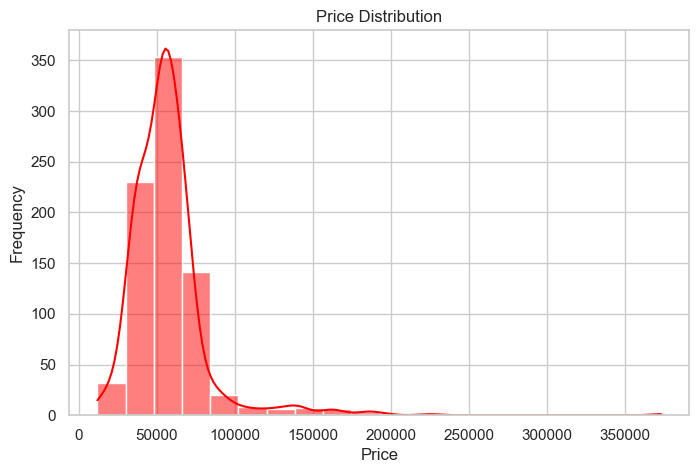

In [41]:
# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=20, color="Red", kde= True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Shows how laptop prices are distributed
# Helps identify minimum price, maximum price, and most common price range

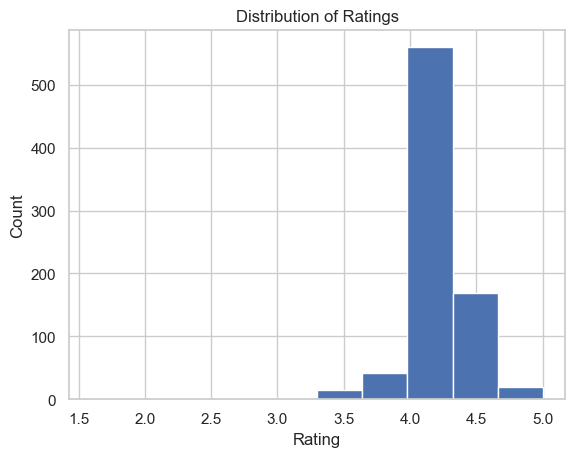

In [33]:
# Rating wise Distribution
plt.figure()
plt.hist(df['Rating'], bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Displays customer rating distribution
# Helps understand customer satisfaction level

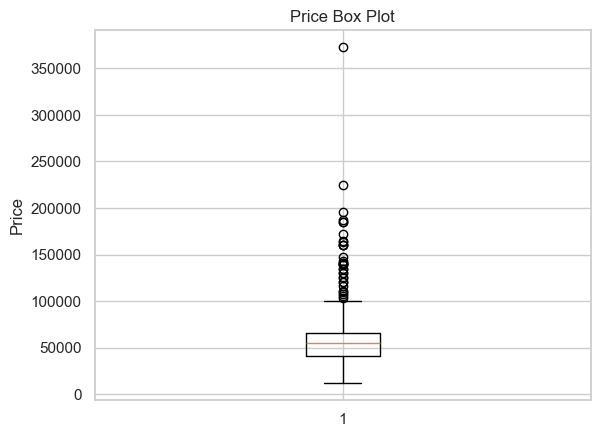

In [42]:
plt.figure()
plt.boxplot(df['Price'])
plt.title('Price Box Plot')
plt.ylabel('Price')
plt.show()

In [43]:
print("Mean:", df['Price'].mean())
print("Median:", df['Price'].median())
print("Mode:", df['Price'].mode())

Mean: 56940.99381953028
Median: 54990.0
Mode: 0    66990.0
Name: Price, dtype: float64


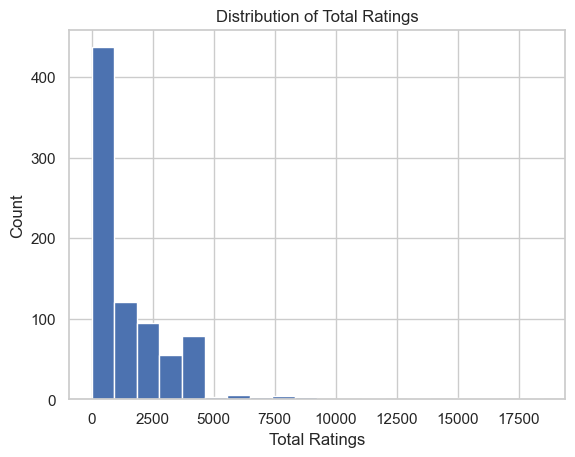

In [37]:
# Total Rating Distribution
plt.figure()
plt.hist(df['Total_Ratings'], bins=20)
plt.title("Distribution of Total Ratings")
plt.xlabel("Total Ratings")
plt.ylabel("Count")
plt.show()

# **2.Bivariate Analysis**

## **1. Price vs Rating**

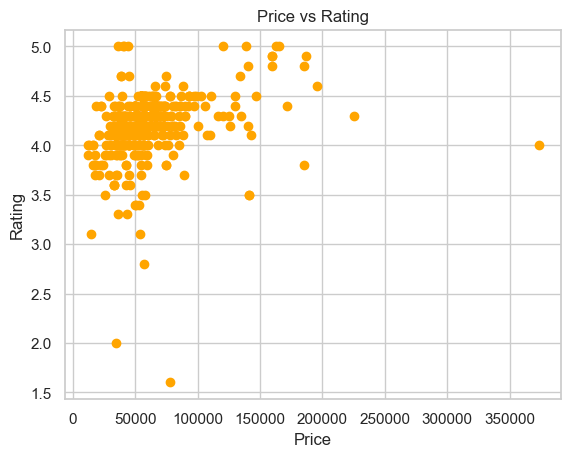

In [21]:
plt.figure()
plt.scatter(df['Price'], df['Rating'], color = "orange")
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

## **2. Price vs Discount**

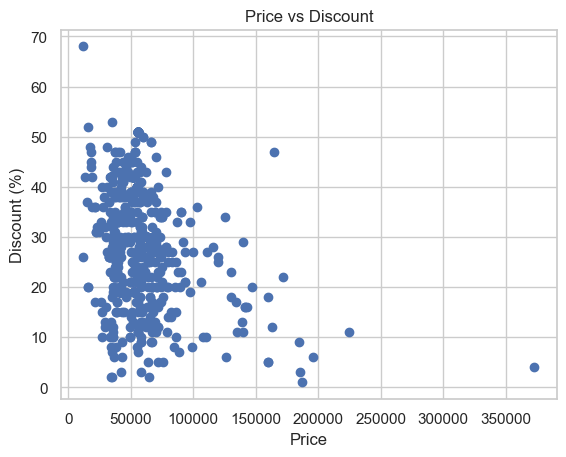

In [7]:
plt.figure()
plt.scatter(df['Price'], df['Discount'])
plt.title("Price vs Discount")
plt.xlabel("Price")
plt.ylabel("Discount (%)")
plt.show()

# Expensive laptops often receive higher discounts
# Low-priced laptops usually have smaller discounts

## **3. Processor vs Price**

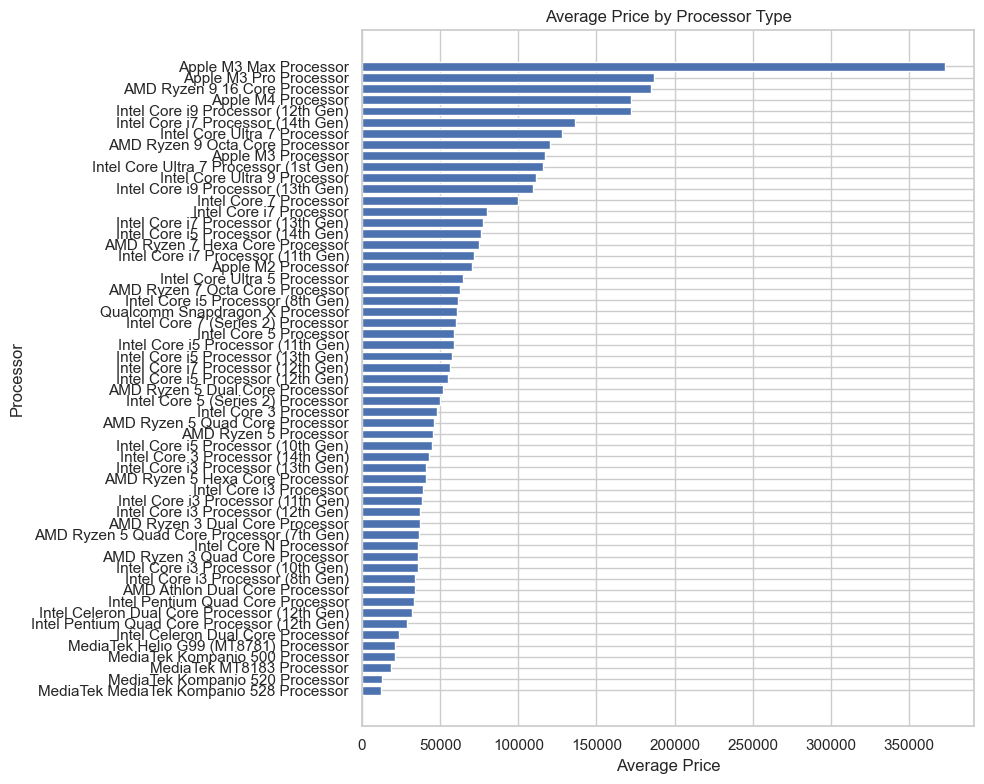

In [16]:
import matplotlib.pyplot as plt

# Group and calculate average price
avg_price = df.groupby('Processor')['Price'].mean().sort_values()

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
plt.barh(avg_price.index, avg_price.values)
plt.title("Average Price by Processor Type")
plt.xlabel("Average Price")
plt.ylabel("Processor")
plt.tight_layout()
plt.show()

## **3. Multivariate Analysis**

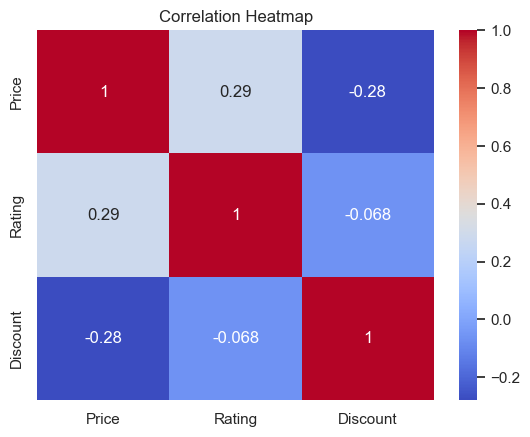

In [26]:
# correlation Heatmap 
corr = df[["Price", "Rating", "Discount"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

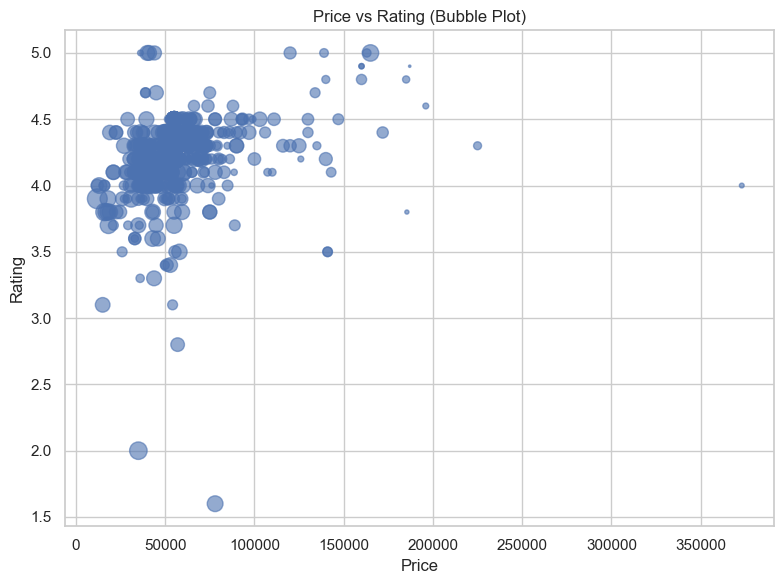

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['Price'],
    df['Rating'],
    s=df['Discount'] * 3,   # bubble size
    alpha=0.6
)

plt.title("Price vs Rating (Bubble Plot)")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()